In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from sklearn.linear_model import LinearRegression

Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...
Coordinates type: 'euclidean' 

Using 'gaussian' Variogram Model
Partial Sill: 16764.93078069566
Full Sill: 24038.751585216578
Range: 0.014569371248927654
Nugget: 7273.820804520917 



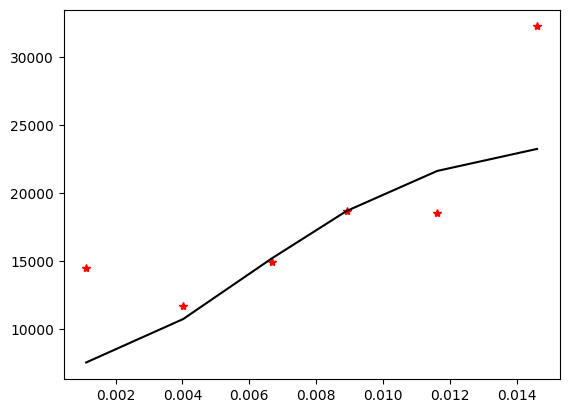

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



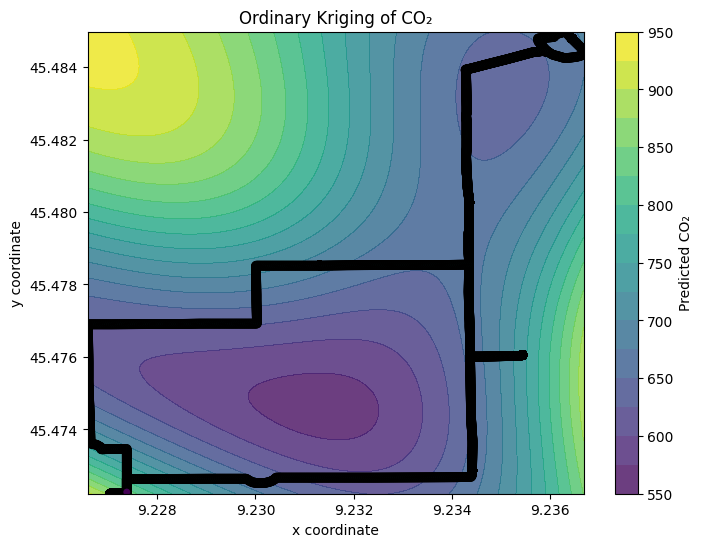

In [ ]:
# 1. Load your data
df = pd.read_csv('../data/processed_data/S1CO2-approx-coordinates.csv')
x = df['x'].values
y = df['y'].values
z = df['CO2'].values

# 2. Fit the ordinary kriging model
#    Choose variogram_model among: 'linear', 'power', 'gaussian', 'spherical', 'exponential'
ok = OrdinaryKriging(
    x, y, z,
    variogram_model='gaussian',
    verbose=True,
    enable_plotting=True
)

# 3. Create a regular grid covering your data’s extent
npts = 300
gridx = np.linspace(x.min(), x.max(), npts)
gridy = np.linspace(y.min(), y.max(), npts)

# 4. Perform kriging on the grid
zgrid, ss = ok.execute('grid', gridx, gridy)

# 5. Plot the interpolated surface + sampling points
fig, ax = plt.subplots(figsize=(8, 6))

# Filled contours of predicted CO2
c = ax.contourf(gridx, gridy, zgrid, levels=15, 
                cmap='viridis', alpha=0.8)

# Scatter raw observations
sc = ax.scatter(x, y, c=z, edgecolor='k', cmap='viridis')

ax.set_xlabel('x coordinate')
ax.set_ylabel('y coordinate')
ax.set_title('Ordinary Kriging of CO₂')

fig.colorbar(c, ax=ax, label='Predicted CO₂')
plt.show()


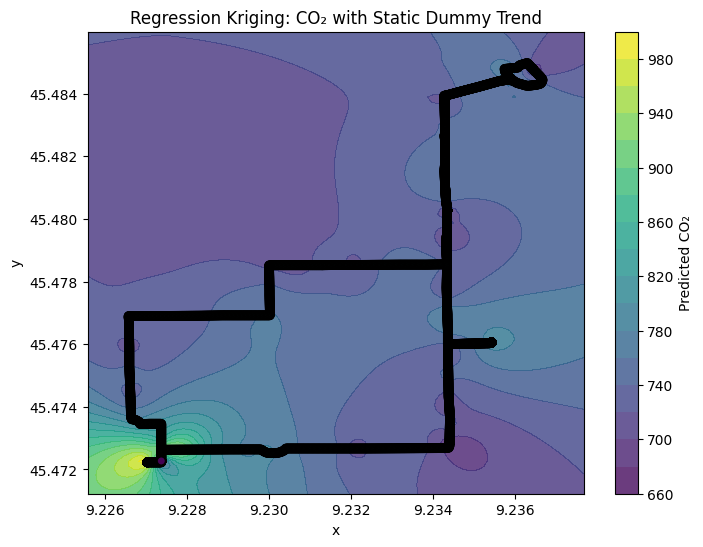

In [ ]:
# 1. Load data
df = pd.read_csv('../data/processed_data/S1CO2-approx-coordinates.csv')

# 2. Create a 0/1 dummy for 'static' regime
df['static_dummy'] = (df['regime'] == 'static').astype(int)

# 3. Prepare arrays
x = df['x'].values
y = df['y'].values
z = df['CO2'].values
d = df['static_dummy'].values.reshape(-1, 1)

# 4. Fit a simple OLS of CO2 on the dummy
reg = LinearRegression().fit(d, z)
trend_at_samples = reg.predict(d)

# 5. Compute residuals
residuals = z - trend_at_samples

# 6. Krige residuals with Ordinary Kriging
ok = OrdinaryKriging(
    x, y, residuals,
    variogram_model='spherical',
    verbose=False,
    enable_plotting=False
)

# 7. Define a prediction grid
gridx = np.linspace(x.min() - 0.001, x.max() + 0.001, 100)
gridy = np.linspace(y.min() - 0.001, y.max() + 0.001, 100)

# 8. Krige residuals on the grid
resid_pred_grid, ss = ok.execute('grid', gridx, gridy)

# 9. Build trend grid
#    Here you need a grid of dummy values: supply 0 or 1 per cell.
#    For illustration, we assume all grid cells are 'static' (1).
grid_dummy = np.ones((gridy.size, gridx.size))
trend_grid = reg.intercept_ + reg.coef_[0] * grid_dummy

# 10. Combine trend + residual surface
z_pred_grid = trend_grid + resid_pred_grid

# 11. Plot final surface
plt.figure(figsize=(8, 6))
cs = plt.contourf(gridx, gridy, z_pred_grid, levels=15, cmap='viridis', alpha=0.8)
plt.scatter(x, y, c=z, edgecolor='k', cmap='viridis')
plt.title("Regression Kriging: CO₂ with Static Dummy Trend")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(cs, label="Predicted CO₂")
plt.show()
